# Machine Learning – Unidad 1
## Pipeline Reproducible: House Prices – Advanced Regression Techniques

**Curso:** Machine Learning  
**Institución:** Universidad Mayor  
**Dataset:** [House Prices – Kaggle](https://www.kaggle.com/c/house-prices-advanced-regression-techniques)  
**Integrantes:**
-Camilo Olivares

**Repositorio GitHub:** [https://github.com/tu-usuario/ml-unidad1-house-prices](https://github.com/tu-usuario/ml-unidad1-house-prices)

---
## Introducción

Este trabajo tiene como objetivo construir un **pipeline reproducible de Machine Learning** aplicado al dataset *House Prices – Advanced Regression Techniques* de Kaggle. El problema consiste en predecir el precio de venta de viviendas en Ames, Iowa (EE.UU.), a partir de 79 variables explicativas que describen aspectos físicos, de calidad y ubicación de cada propiedad.

El pipeline abarca:
1. Presentación y comparación de frameworks de analítica de datos.
2. Exploración, limpieza y tratamiento de calidad de datos.
3. Métodos de separación en ventanas de entrenamiento, validación y test.
4. Repositorio público en GitHub con todo el desarrollo.

El análisis busca ser **transparente, reproducible y bien documentado**, siguiendo buenas prácticas de ciencia de datos.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train.csv


---
## Instalación de dependencias

In [ ]:
# Importaciones generales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, KFold, TimeSeriesSplit
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

print('✅ Librerías importadas correctamente')

✅ Librerías importadas correctamente


---
# PUNTO 1: Frameworks para Analítica de Datos

A continuación se presentan tres frameworks ampliamente utilizados en proyectos de ciencia de datos y Machine Learning aplicado a datos tabulares.

## 1.1 Pandas

### Descripción
**Pandas** es una librería de código abierto para Python, construida sobre NumPy. Su estructura principal es el `DataFrame`, una tabla bidimensional con etiquetas que permite manipular y analizar datos de forma intuitiva y eficiente. Es el estándar de facto en ciencia de datos para el procesamiento de datos tabulares (McKinney, 2010).

### Alcances
- Lectura y escritura de múltiples formatos: CSV, Excel, SQL, JSON, Parquet, HDF5.
- Operaciones de filtrado, agrupación (`groupby`), merge/join similares a SQL.
- Manejo nativo de datos faltantes (`NaN`).
- Integración directa con Matplotlib/Seaborn para visualización.
- Soporte para datos de series de tiempo con índices temporales.
- Ideal para EDA (Exploratory Data Analysis) y preprocesamiento.

### Limitaciones
- Opera completamente **en memoria RAM**: archivos mayores a ~1–2 GB pueden saturar el sistema.
- Procesamiento **single-threaded** por defecto; no escala bien a Big Data.
- No incluye algoritmos de Machine Learning (debe combinarse con scikit-learn, etc.).
- Para datos no tabulares (texto, imágenes) no es la herramienta adecuada.

## 1.2 Scikit-learn

### Descripción
**Scikit-learn** es la biblioteca de Machine Learning más popular para Python. Proporciona implementaciones eficientes de algoritmos de clasificación, regresión, clustering, reducción dimensional y selección de características, todo bajo una API consistente basada en el patrón `fit / transform / predict` (Pedregosa et al., 2011).

### Alcances
- Amplio catálogo de modelos: regresión lineal, árbol de decisión, Random Forest, SVM, KNN, etc.
- Pipeline integrado (`sklearn.pipeline.Pipeline`) para encadenar preprocesamiento y modelado.
- Herramientas de validación cruzada, búsqueda de hiperparámetros (`GridSearchCV`, `RandomizedSearchCV`).
- Métricas de evaluación para regresión y clasificación.
- `ColumnTransformer` para aplicar transformaciones diferenciadas por tipo de columna.

### Limitaciones
- No incluye redes neuronales profundas (para eso se usa TensorFlow o PyTorch).
- Entrenamiento en **CPU** sin soporte nativo para GPU.
- Menor rendimiento que librerías especializadas como XGBoost o LightGBM en datasets muy grandes.
- No está diseñado para datos no estructurados (imágenes, texto en bruto, audio).

## 1.3 TensorFlow / Keras

### Descripción
**TensorFlow** es un framework de código abierto desarrollado por Google para computación numérica y aprendizaje profundo. **Keras** es su API de alto nivel que permite construir y entrenar redes neuronales de forma sencilla (Abadi et al., 2016). Es el estándar industrial para Deep Learning.

### Alcances
- Construcción de redes neuronales de cualquier arquitectura: densas, convolucionales (CNN), recurrentes (RNN/LSTM), transformers.
- Soporte para entrenamiento en **GPU y TPU**, lo que permite manejar grandes volúmenes de datos.
- Capacidades de producción: exportar modelos a TensorFlow Serving, TFLite (móvil), TensorFlow.js (web).
- TensorBoard para visualización interactiva del entrenamiento.
- Ecosistema amplio: TF-Data, TF-Hub, TF-Probability.

### Limitaciones
- Curva de aprendizaje más pronunciada que scikit-learn.
- Para datos tabulares simples, es sobredimensionado frente a scikit-learn.
- Requiere más recursos computacionales y configuración de entorno.
- El debugging de grafos de cómputo puede ser complejo.

## 1.4 Tabla Comparativa de Frameworks

In [ ]:
comparacion = pd.DataFrame({
    'Criterio': [
        'Tipo de datos', 'Facilidad de uso', 'Escalabilidad',
        'ML integrado', 'Deep Learning', 'GPU/TPU', 'Producción'
    ],
    'Pandas': [
        'Tabular', '⭐⭐⭐⭐⭐', 'Baja (RAM)',
        '❌', '❌', '❌', 'Media'
    ],
    'Scikit-learn': [
        'Tabular / vectorial', '⭐⭐⭐⭐', 'Media',
        '✅', '❌', '❌', 'Media'
    ],
    'TensorFlow/Keras': [
        'Todo tipo', '⭐⭐⭐', 'Alta',
        '✅', '✅', '✅', 'Alta'
    ]
})

print('\n📊 Comparación de Frameworks:')
print(comparacion.to_string(index=False))


📊 Comparación de Frameworks:
        Criterio     Pandas        Scikit-learn TensorFlow/Keras
   Tipo de datos    Tabular Tabular / vectorial        Todo tipo
Facilidad de uso      ⭐⭐⭐⭐⭐                ⭐⭐⭐⭐              ⭐⭐⭐
   Escalabilidad Baja (RAM)               Media             Alta
    ML integrado          ❌                   ✅                ✅
   Deep Learning          ❌                   ❌                ✅
         GPU/TPU          ❌                   ❌                ✅
      Producción      Media               Media             Alta


## 1.5 Framework Seleccionado para este Proyecto

Para este trabajo se utilizará la combinación **Pandas + Scikit-learn**, por las siguientes razones:

- El dataset House Prices es **tabular y de tamaño manejable** (~1,500 registros de entrenamiento), por lo que no se requiere escalabilidad de Big Data.
- Scikit-learn ofrece todo lo necesario para regresión, preprocesamiento y validación en un entorno unificado.
- Pandas es ideal para la exploración, limpieza y transformación de datos previos al modelado.
- La integración entre ambas librerías es nativa y bien documentada.
- TensorFlow estaría **sobredimensionado** para este caso de uso tabular con pocos miles de registros.

---
# PUNTO 2: Calidad de Datos

## 2.1 Carga del Dataset

> **Instrucción:** Descarga el dataset desde [Kaggle House Prices](https://www.kaggle.com/c/house-prices-advanced-regression-techniques/data) y guarda `train.csv` en la misma carpeta que este notebook.

In [57]:
# Carga del dataset de entrenamiento
df = pd.read_csv('train.csv')

print(f'📐 Dimensiones del dataset: {df.shape[0]} filas × {df.shape[1]} columnas')
print(f'🎯 Variable objetivo: SalePrice')
df.head()

📐 Dimensiones del dataset: 1460 filas × 81 columnas
🎯 Variable objetivo: SalePrice


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 2.2 Exploración General de los Datos

In [ ]:
# Tipos de datos
print('📋 Tipos de datos por columna:')
print(f"  - Numéricas: {df.select_dtypes(include=np.number).shape[1]} columnas")
print(f"  - Categóricas (object): {df.select_dtypes(include='object').shape[1]} columnas")

📋 Tipos de datos por columna:
  - Numéricas: 38 columnas
  - Categóricas (object): 43 columnas


In [58]:
# Estadísticas descriptivas de variables numéricas
print('📊 Estadísticas descriptivas (variables numéricas):')
df.describe().T

📊 Estadísticas descriptivas (variables numéricas):


,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [59]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

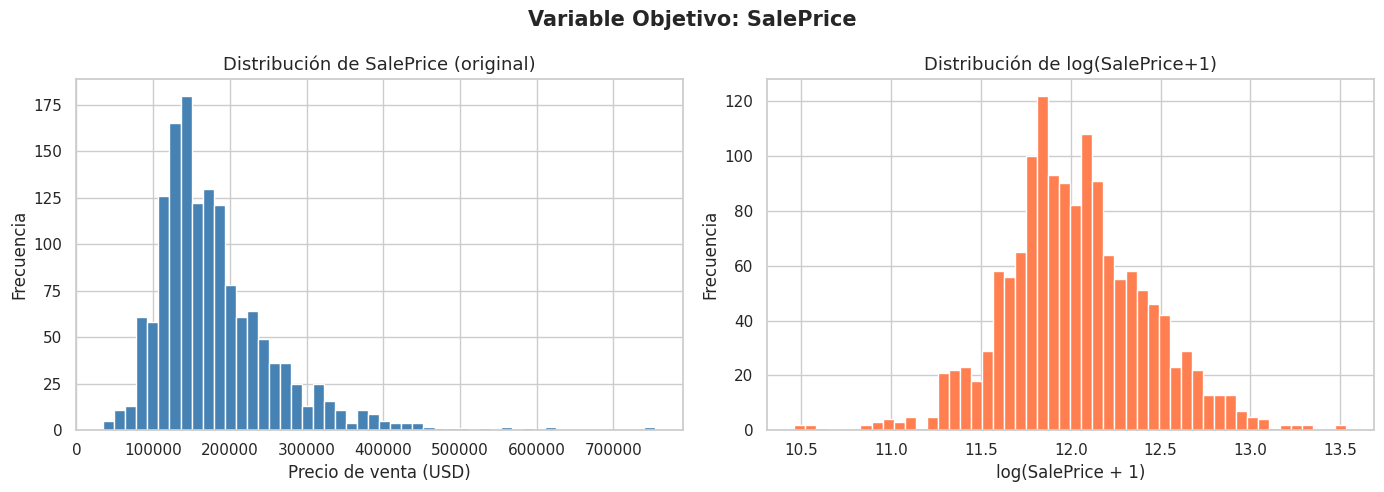


📈 Estadísticas de SalePrice:
  Media:    $180,921
  Mediana:  $163,000
  Mínimo:   $34,900
  Máximo:   $755,000
  Asimetría: 1.883 (distribución sesgada a la derecha → aplicar log)


In [62]:
# Distribución de la variable objetivo: SalePrice
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['SalePrice'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución de SalePrice (original)', fontsize=13)
axes[0].set_xlabel('Precio de venta (USD)')
axes[0].set_ylabel('Frecuencia')

axes[1].hist(np.log1p(df['SalePrice']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('Distribución de log(SalePrice+1)', fontsize=13)
axes[1].set_xlabel('log(SalePrice + 1)')
axes[1].set_ylabel('Frecuencia')

plt.suptitle('Variable Objetivo: SalePrice', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n📈 Estadísticas de SalePrice:')
print(f'  Media:    ${df["SalePrice"].mean():,.0f}')
print(f'  Mediana:  ${df["SalePrice"].median():,.0f}')
print(f'  Mínimo:   ${df["SalePrice"].min():,.0f}')
print(f'  Máximo:   ${df["SalePrice"].max():,.0f}')
print(f'  Asimetría: {df["SalePrice"].skew():.3f} (distribución sesgada a la derecha → aplicar log)')

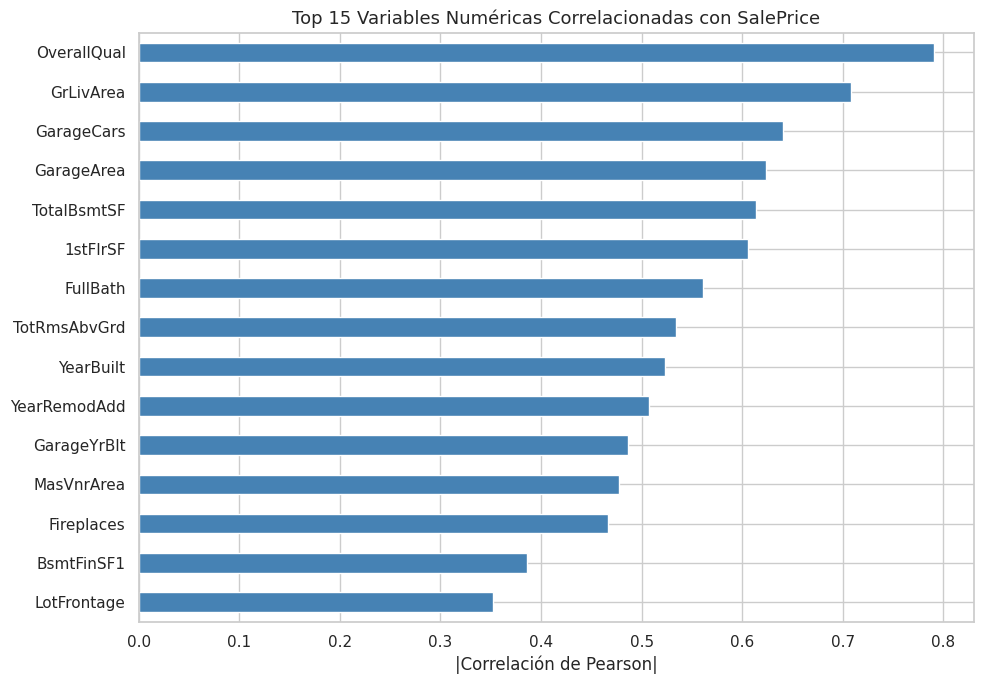


🔗 Top 10 correlaciones con SalePrice:
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101


In [63]:
# Correlación de variables numéricas con SalePrice (Top 15)
num_cols = df.select_dtypes(include=np.number).columns.tolist()
correlaciones = df[num_cols].corr()['SalePrice'].drop('SalePrice').abs().sort_values(ascending=False)

plt.figure(figsize=(10, 7))
correlaciones.head(15).plot(kind='barh', color='steelblue')
plt.title('Top 15 Variables Numéricas Correlacionadas con SalePrice', fontsize=13)
plt.xlabel('|Correlación de Pearson|')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print('\n🔗 Top 10 correlaciones con SalePrice:')
print(correlaciones.head(10).to_string())

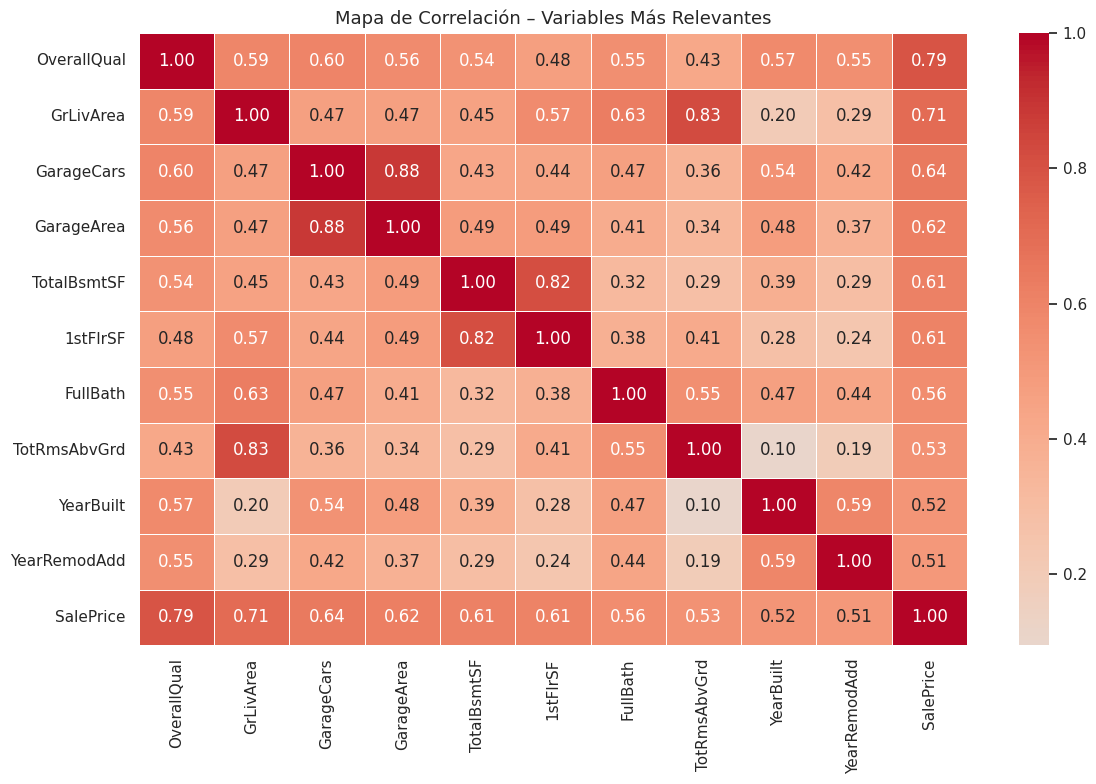

In [64]:
# Heatmap de correlación (variables más relevantes)
top_vars = correlaciones.head(10).index.tolist() + ['SalePrice']

plt.figure(figsize=(12, 8))
sns.heatmap(
    df[top_vars].corr(),
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5
)
plt.title('Mapa de Correlación – Variables Más Relevantes', fontsize=13)
plt.tight_layout()
plt.show()

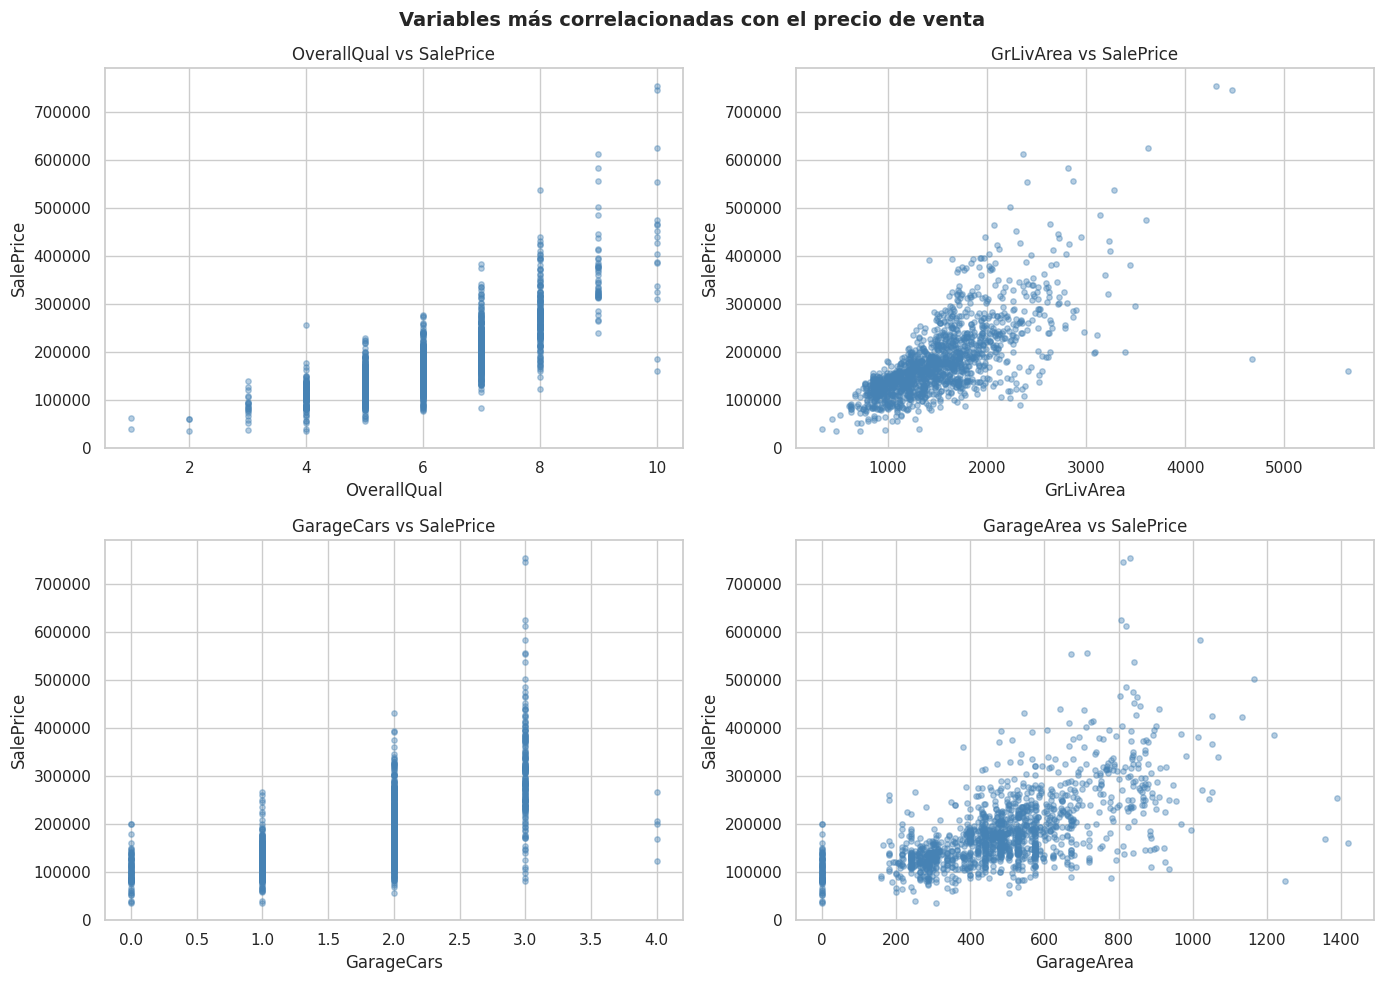

In [65]:
# Scatter plots de las 4 variables más correlacionadas
top4 = correlaciones.head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(top4):
    axes[i].scatter(df[col], df['SalePrice'], alpha=0.4, color='steelblue', s=15)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('SalePrice')
    axes[i].set_title(f'{col} vs SalePrice')

plt.suptitle('Variables más correlacionadas con el precio de venta', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Interpretación de la Exploración

- **SalePrice** presenta una distribución **asimétrica positiva (skew ≈ 1.88)**: la mayoría de las casas se vende entre USD 100,000 y USD 300,000, con algunas propiedades de lujo que extienden la cola derecha. Se recomienda aplicar **transformación logarítmica** antes de modelar.
- Las variables con mayor correlación con el precio son `OverallQual` (calidad general), `GrLivArea` (superficie habitable), `GarageCars` y `TotalBsmtSF` (superficie del sótano).
- Existen **79 variables explicativas** (36 numéricas + 43 categóricas), lo que requiere un preprocesamiento cuidadoso.

---
## 2.3 Limpieza de Datos

### 2.3.1 Identificación y Tratamiento de Valores Faltantes (Missing Values)

In [66]:
# Análisis de valores faltantes
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Columna': missing.index,
    'Valores Faltantes': missing.values,
    'Porcentaje (%)': missing_pct.values
})

print(f'🔍 Columnas con valores faltantes: {len(missing_df)} de {df.shape[1]}')
print()
print(missing_df.to_string(index=False))

🔍 Columnas con valores faltantes: 19 de 81

     Columna  Valores Faltantes  Porcentaje (%)
      PoolQC               1453           99.52
 MiscFeature               1406           96.30
       Alley               1369           93.77
       Fence               1179           80.75
  MasVnrType                872           59.73
 FireplaceQu                690           47.26
 LotFrontage                259           17.74
  GarageType                 81            5.55
 GarageYrBlt                 81            5.55
GarageFinish                 81            5.55
  GarageQual                 81            5.55
  GarageCond                 81            5.55
BsmtExposure                 38            2.60
BsmtFinType2                 38            2.60
    BsmtQual                 37            2.53
    BsmtCond                 37            2.53
BsmtFinType1                 37            2.53
  MasVnrArea                  8            0.55
  Electrical                  1            0

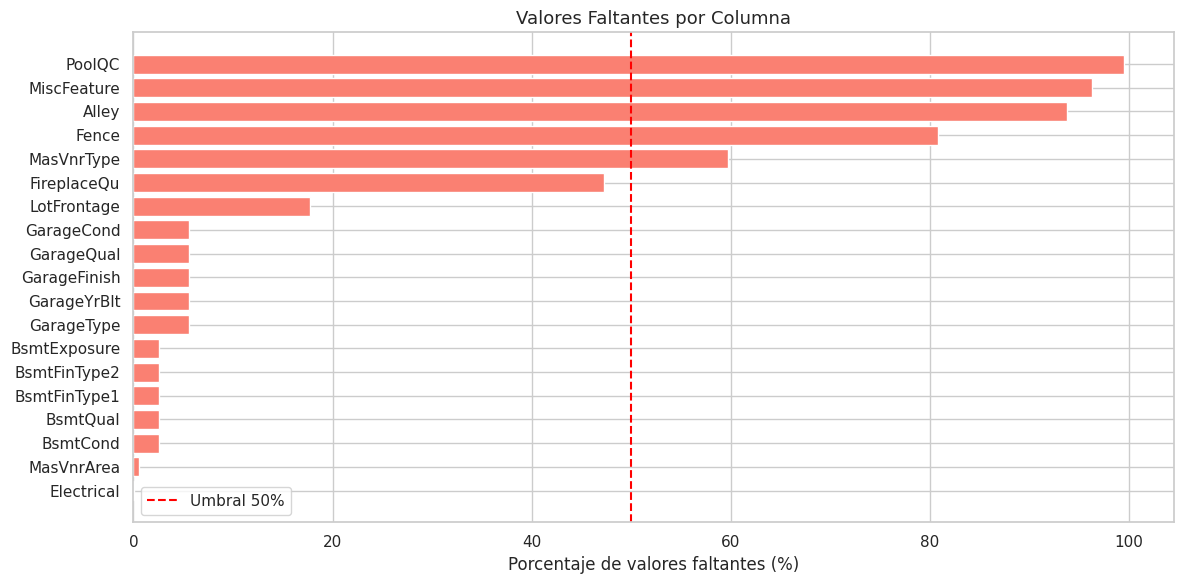

In [67]:
# Visualización de missing values
plt.figure(figsize=(12, 6))
missing_df_plot = missing_df[missing_df['Porcentaje (%)'] > 0].sort_values('Porcentaje (%)', ascending=True)
plt.barh(missing_df_plot['Columna'], missing_df_plot['Porcentaje (%)'], color='salmon')
plt.axvline(x=50, color='red', linestyle='--', label='Umbral 50%')
plt.xlabel('Porcentaje de valores faltantes (%)')
plt.title('Valores Faltantes por Columna', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

In [68]:
# -------------------------------------------------------
# ESTRATEGIA DE IMPUTACIÓN
# -------------------------------------------------------
# En este dataset, muchos NaN en variables categóricas
# indican ausencia de la característica (ej: sin piscina,
# sin garaje), no un dato perdido real. Se imputa con 'None'.
# Para numéricas, se imputa con 0 o la mediana según el caso.

df_clean = df.copy()

# --- Categóricas: NaN = ausencia de característica → 'None'
cat_none = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
    'BsmtFinType2', 'MasVnrType'
]
for col in cat_none:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna('None')

# --- Numéricas: NaN = ausencia → 0
num_zero = [
    'GarageYrBlt', 'GarageArea', 'GarageCars',
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
    'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea'
]
for col in num_zero:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(0)

# --- LotFrontage: imputa con mediana por vecindario
if 'LotFrontage' in df_clean.columns:
    df_clean['LotFrontage'] = df_clean.groupby('Neighborhood')['LotFrontage'].transform(
        lambda x: x.fillna(x.median())
    )

# --- Electrical: 1 solo NaN → moda
if 'Electrical' in df_clean.columns:
    df_clean['Electrical'] = df_clean['Electrical'].fillna(df_clean['Electrical'].mode()[0])

# Verificación
missing_post = df_clean.isnull().sum().sum()
print(f'✅ Valores faltantes antes: {df.isnull().sum().sum()}')
print(f'✅ Valores faltantes después: {missing_post}')

✅ Valores faltantes antes: 7829
✅ Valores faltantes después: 0


### 2.3.2 Identificación y Tratamiento de Datos Atípicos (Outliers)

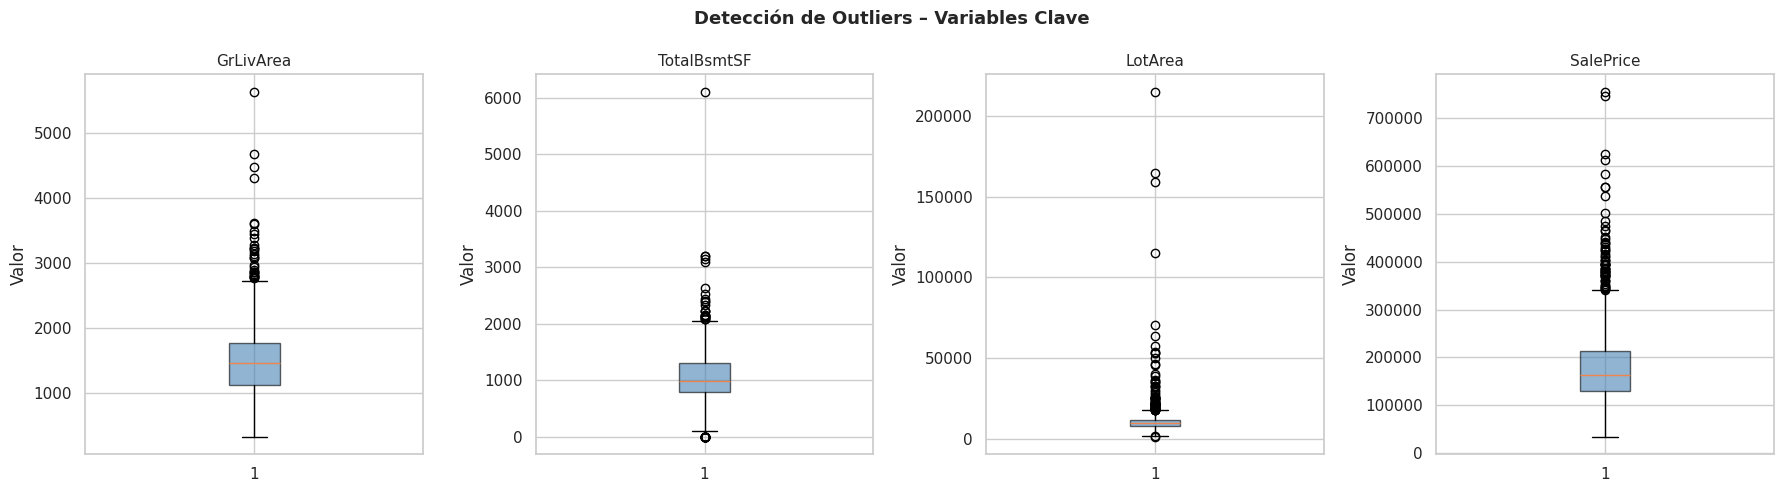

In [69]:
# Boxplots para visualizar outliers en variables clave
vars_outlier = ['GrLivArea', 'TotalBsmtSF', 'LotArea', 'SalePrice']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for i, col in enumerate(vars_outlier):
    axes[i].boxplot(df_clean[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6))
    axes[i].set_title(col, fontsize=11)
    axes[i].set_ylabel('Valor')

plt.suptitle('Detección de Outliers – Variables Clave', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [71]:
# -----------------------------------------------------------
# Método IQR para identificar outliers en GrLivArea
# (Superficie habitable sobre el suelo – variable más relevante)
# -----------------------------------------------------------
def detectar_outliers_iqr(series, nombre):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    outliers = series[(series < lim_inf) | (series > lim_sup)]
    print(f'📌 {nombre}')
    print(f'   Q1={Q1:.1f}, Q3={Q3:.1f}, IQR={IQR:.1f}')
    print(f'   Límite inferior: {lim_inf:.1f}')
    print(f'   Límite superior: {lim_sup:.1f}')
    print(f'   Outliers detectados: {len(outliers)} registros ({len(outliers)/len(series)*100:.1f}%)\n')
    return lim_inf, lim_sup

for var in ['GrLivArea', 'TotalBsmtSF', 'LotArea']:
    detectar_outliers_iqr(df_clean[var].dropna(), var)

📌 GrLivArea
   Q1=1129.5, Q3=1776.8, IQR=647.2
   Límite inferior: 158.6
   Límite superior: 2747.6
   Outliers detectados: 31 registros (2.1%)

📌 TotalBsmtSF
   Q1=795.8, Q3=1298.2, IQR=502.5
   Límite inferior: 42.0
   Límite superior: 2052.0
   Outliers detectados: 61 registros (4.2%)

📌 LotArea
   Q1=7553.5, Q3=11601.5, IQR=4048.0
   Límite inferior: 1481.5
   Límite superior: 17673.5
   Outliers detectados: 69 registros (4.7%)



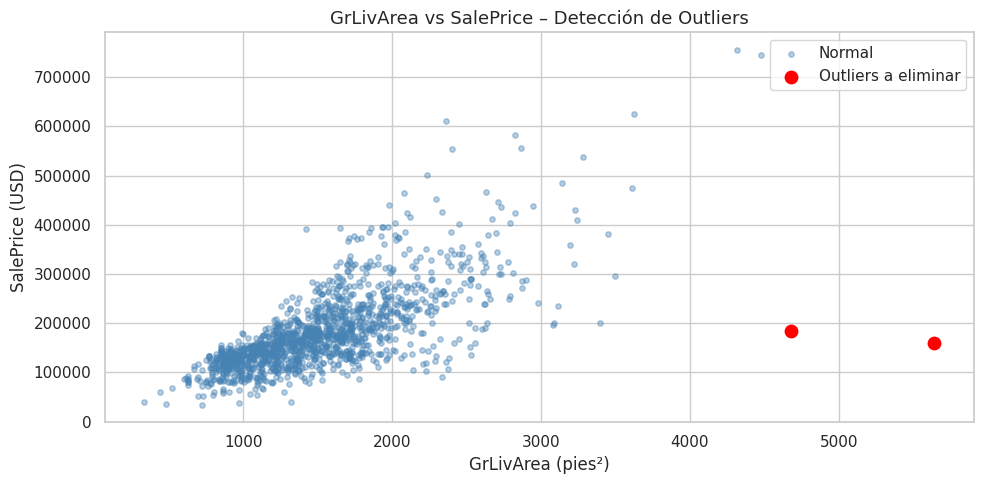

✅ Registros antes: 1460
✅ Registros después de eliminar outliers: 1458
   Eliminados: 2 registros


In [72]:
# -----------------------------------------------------------
# Tratamiento de outliers en GrLivArea:
# El data description de Kaggle advierte que hay 2 casas
# con GrLivArea > 4000 pies² vendidas a precio anormalmente bajo.
# Se eliminan por ser casos especiales que distorsionarían el modelo.
# -----------------------------------------------------------
n_antes = len(df_clean)

# Visualización del problema
plt.figure(figsize=(10, 5))
plt.scatter(df_clean['GrLivArea'], df_clean['SalePrice'],
            alpha=0.4, color='steelblue', s=15, label='Normal')
outliers_mask = (df_clean['GrLivArea'] > 4000) & (df_clean['SalePrice'] < 300000)
plt.scatter(df_clean.loc[outliers_mask, 'GrLivArea'],
            df_clean.loc[outliers_mask, 'SalePrice'],
            color='red', s=80, zorder=5, label='Outliers a eliminar')
plt.xlabel('GrLivArea (pies²)')
plt.ylabel('SalePrice (USD)')
plt.title('GrLivArea vs SalePrice – Detección de Outliers', fontsize=13)
plt.legend()
plt.tight_layout()
plt.show()

# Eliminación de outliers problemáticos
df_clean = df_clean[~outliers_mask].reset_index(drop=True)

print(f'✅ Registros antes: {n_antes}')
print(f'✅ Registros después de eliminar outliers: {len(df_clean)}')
print(f'   Eliminados: {n_antes - len(df_clean)} registros')

In [73]:
# -----------------------------------------------------------
# Tratamiento de outliers en LotArea:
# Se aplica winsorización al percentil 99 (cap) para
# preservar los registros pero limitar el impacto de valores extremos.
# -----------------------------------------------------------
p99_lot = df_clean['LotArea'].quantile(0.99)
n_capped = (df_clean['LotArea'] > p99_lot).sum()
df_clean['LotArea'] = df_clean['LotArea'].clip(upper=p99_lot)

print(f'📌 Winsorización LotArea:')
print(f'   Percentil 99: {p99_lot:,.0f} pies²')
print(f'   Valores capados: {n_capped}')

📌 Winsorización LotArea:
   Percentil 99: 35,403 pies²
   Valores capados: 15


In [74]:
# Resumen final del dataset limpio
print('=' * 50)
print('📊 RESUMEN DEL DATASET DESPUÉS DE LA LIMPIEZA')
print('=' * 50)
print(f'  Filas:              {df_clean.shape[0]}')
print(f'  Columnas:           {df_clean.shape[1]}')
print(f'  Valores faltantes:  {df_clean.isnull().sum().sum()}')
print(f'  Variable objetivo:  SalePrice')
print(f'  Media SalePrice:    ${df_clean["SalePrice"].mean():,.0f}')

📊 RESUMEN DEL DATASET DESPUÉS DE LA LIMPIEZA
  Filas:              1458
  Columnas:           81
  Valores faltantes:  0
  Variable objetivo:  SalePrice
  Media SalePrice:    $180,933


---
# PUNTO 3: Ventanas de Desarrollo / Validación / Test

Para evaluar el rendimiento de un modelo de ML es fundamental **no usar los mismos datos para entrenar y evaluar**. A continuación se presentan tres métodos de splitting.

### Preparación de features para el splitting

In [77]:
# Preparación rápida de features para demostrar el splitting
# (Encoding simple de categóricas)
df_model = df_clean.copy()

# Codificación de variables categóricas con Label Encoding
cat_cols = df_model.select_dtypes(include='object').columns
le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# Variables independientes y variable objetivo
X = df_model.drop(['SalePrice', 'Id'], axis=1)
y = np.log1p(df_model['SalePrice'])  # Transformación logarítmica

print(f'✅ Shape de X: {X.shape}')
print(f'✅ Shape de y: {y.shape}')
print(f'   Variables predictoras: {X.shape[1]}')

✅ Shape de X: (1458, 79)
✅ Shape de y: (1458,)
   Variables predictoras: 79


---
## Método 1: Holdout Simple (Train / Validation / Test)

**Descripción:** División aleatoria del dataset en tres subconjuntos fijos: entrenamiento (70%), validación (15%) y test (15%). Es el método más simple y directo.

**Ventajas:**
- Muy rápido y fácil de implementar.
- Adecuado cuando el dataset es grande.

**Desventajas:**
- La estimación del error depende de cómo se realiza la partición aleatoria.
- Con datasets pequeños, una mala división puede llevar a conclusiones erróneas.
- No aprovecha todos los datos para entrenamiento.

In [78]:
# ─── Método 1: Holdout Simple ────────────────────────────
# División: 70% train | 15% val | 15% test
SEED = 42

X_temp, X_test_ho, y_temp, y_test_ho = train_test_split(
    X, y, test_size=0.15, random_state=SEED
)

X_train_ho, X_val_ho, y_train_ho, y_val_ho = train_test_split(
    X_temp, y_temp, test_size=0.15/0.85, random_state=SEED
)

print('━' * 45)
print('  MÉTODO 1: HOLDOUT SIMPLE')
print('━' * 45)
print(f'  Train:      {len(X_train_ho):>5} registros  ({len(X_train_ho)/len(X)*100:.1f}%)')
print(f'  Validación: {len(X_val_ho):>5} registros  ({len(X_val_ho)/len(X)*100:.1f}%)')
print(f'  Test:       {len(X_test_ho):>5} registros  ({len(X_test_ho)/len(X)*100:.1f}%)')
print(f'  Total:      {len(X):>5} registros')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MÉTODO 1: HOLDOUT SIMPLE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Train:       1020 registros  (70.0%)
  Validación:   219 registros  (15.0%)
  Test:         219 registros  (15.0%)
  Total:       1458 registros


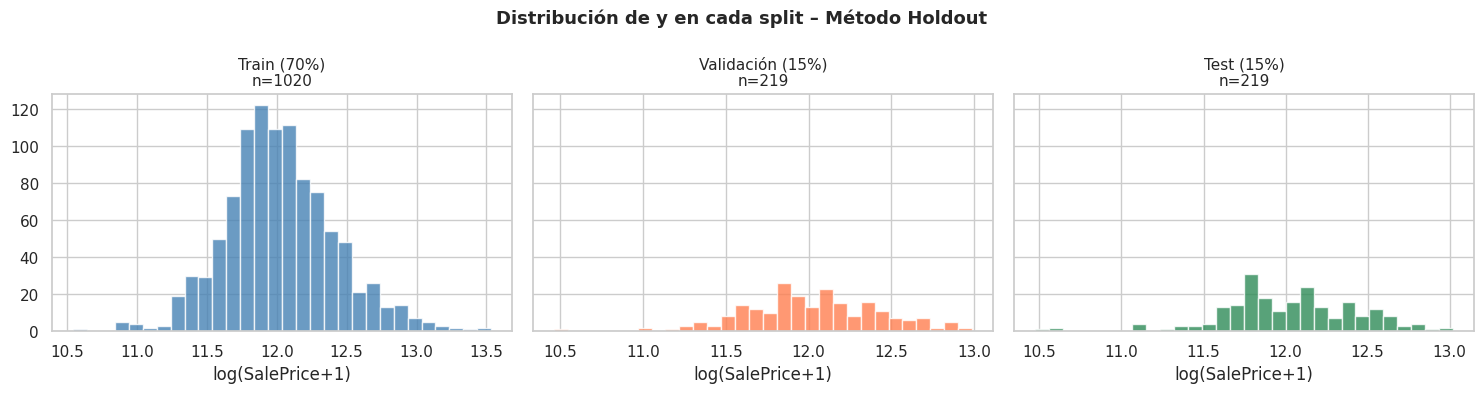

In [79]:
# Visualización de la distribución de y en cada split
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
splits = [(y_train_ho, 'Train (70%)', 'steelblue'),
          (y_val_ho,   'Validación (15%)', 'coral'),
          (y_test_ho,  'Test (15%)', 'seagreen')]

for ax, (data, label, color) in zip(axes, splits):
    ax.hist(data, bins=30, color=color, alpha=0.8, edgecolor='white')
    ax.set_title(f'{label}\nn={len(data)}', fontsize=11)
    ax.set_xlabel('log(SalePrice+1)')

plt.suptitle('Distribución de y en cada split – Método Holdout', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Método 2: K-Fold Cross Validation (k=5)

**Descripción:** El dataset se divide en `k` partes (folds) iguales. El modelo se entrena `k` veces, usando cada vez `k-1` folds para entrenamiento y 1 fold como validación. Finalmente se separa un conjunto test externo fijo.

**Ventajas:**
- Estimación más robusta del error de generalización.
- Todos los datos son usados para entrenamiento y validación.
- Reduce la varianza de la estimación de rendimiento.

**Desventajas:**
- Más costoso computacionalmente (entrena `k` veces).
- No captura dependencias temporales en series de tiempo.

In [80]:
# ─── Método 2: K-Fold Cross Validation (k=5) ─────────────
X_dev, X_test_kf, y_dev, y_test_kf = train_test_split(
    X, y, test_size=0.15, random_state=SEED
)

kf = KFold(n_splits=5, shuffle=True, random_state=SEED)

print('━' * 55)
print('  MÉTODO 2: K-FOLD CROSS VALIDATION (k=5)')
print('━' * 55)
print(f'  Test externo fijo: {len(X_test_kf)} registros ({len(X_test_kf)/len(X)*100:.1f}%)')
print(f'  Dataset desarrollo: {len(X_dev)} registros ({len(X_dev)/len(X)*100:.1f}%)')
print()

for fold, (train_idx, val_idx) in enumerate(kf.split(X_dev), 1):
    X_tr = X_dev.iloc[train_idx]
    X_vl = X_dev.iloc[val_idx]
    print(f'  Fold {fold}: Train={len(X_tr):>4} | Val={len(X_vl):>4}  '
          f'(train {len(X_tr)/len(X_dev)*100:.0f}% / val {len(X_vl)/len(X_dev)*100:.0f}%)')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MÉTODO 2: K-FOLD CROSS VALIDATION (k=5)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Test externo fijo: 219 registros (15.0%)
  Dataset desarrollo: 1239 registros (85.0%)

  Fold 1: Train= 991 | Val= 248  (train 80% / val 20%)
  Fold 2: Train= 991 | Val= 248  (train 80% / val 20%)
  Fold 3: Train= 991 | Val= 248  (train 80% / val 20%)
  Fold 4: Train= 991 | Val= 248  (train 80% / val 20%)
  Fold 5: Train= 992 | Val= 247  (train 80% / val 20%)


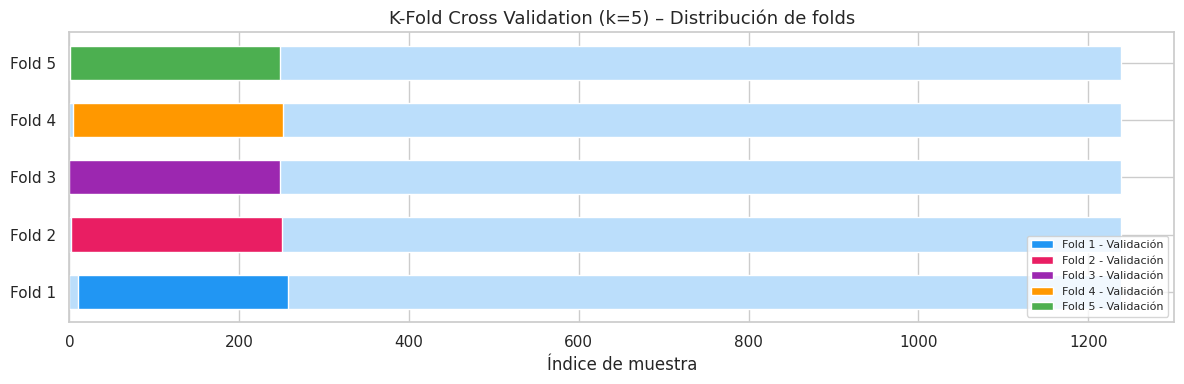

In [81]:
# Diagrama visual de K-Fold
fig, ax = plt.subplots(figsize=(12, 4))
colors = ['#2196F3', '#E91E63', '#9C27B0', '#FF9800', '#4CAF50']

fold_indices = list(kf.split(X_dev))
n_dev = len(X_dev)

for fold_i, (train_idx, val_idx) in enumerate(fold_indices):
    # Fondo gris = train
    ax.barh(fold_i, n_dev, color='#BBDEFB', height=0.6)
    # Color = validación
    val_start = val_idx.min()
    val_len = len(val_idx)
    ax.barh(fold_i, val_len, left=val_start, color=colors[fold_i], height=0.6,
            label=f'Fold {fold_i+1} - Validación')

ax.set_yticks(range(5))
ax.set_yticklabels([f'Fold {i+1}' for i in range(5)])
ax.set_xlabel('Índice de muestra')
ax.set_title('K-Fold Cross Validation (k=5) – Distribución de folds', fontsize=13)
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout()
plt.show()

---
## Método 3: Stratified Split por Calidad de Vivienda (OverallQual)

**Descripción:** División estratificada que garantiza que cada subconjunto mantenga la misma distribución de la variable `OverallQual` (calidad general de la vivienda, escala 1-10), que es la variable más correlacionada con el precio.

**Ventajas:**
- Garantiza representatividad de cada categoría en los tres conjuntos.
- Evita que un split aleatorio concentre todas las casas de baja o alta calidad en un solo subconjunto.
- Reduce el sesgo de selección.

**Desventajas:**
- Requiere definir la variable de estratificación (no siempre evidente).
- Si la variable de estratificación tiene muchas categorías con pocos registros, puede fallar.

In [82]:
# ─── Método 3: Stratified Split ──────────────────────────
strat_col = df_clean['OverallQual'].loc[X.index]  # Asegurar alineación

X_temp_s, X_test_s, y_temp_s, y_test_s, strat_temp, _ = train_test_split(
    X, y, strat_col, test_size=0.15, random_state=SEED, stratify=strat_col
)

X_train_s, X_val_s, y_train_s, y_val_s = train_test_split(
    X_temp_s, y_temp_s, test_size=0.15/0.85, random_state=SEED, stratify=strat_temp
)

print('━' * 50)
print('  MÉTODO 3: STRATIFIED SPLIT (por OverallQual)')
print('━' * 50)
print(f'  Train:      {len(X_train_s):>5} registros  ({len(X_train_s)/len(X)*100:.1f}%)')
print(f'  Validación: {len(X_val_s):>5} registros  ({len(X_val_s)/len(X)*100:.1f}%)')
print(f'  Test:       {len(X_test_s):>5} registros  ({len(X_test_s)/len(X)*100:.1f}%)')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MÉTODO 3: STRATIFIED SPLIT (por OverallQual)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Train:       1020 registros  (70.0%)
  Validación:   219 registros  (15.0%)
  Test:         219 registros  (15.0%)


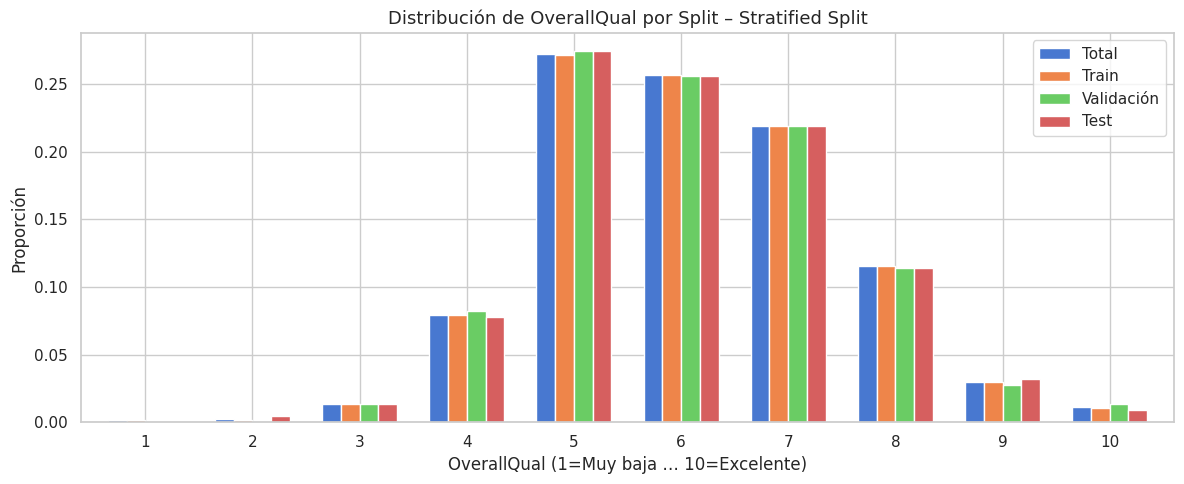


📊 Distribución de OverallQual (proporciones):
             Total  Train  Validación   Test
OverallQual                                 
1            0.001  0.002       0.000  0.000
2            0.002  0.002       0.000  0.005
3            0.014  0.014       0.014  0.014
4            0.080  0.079       0.082  0.078
5            0.272  0.272       0.274  0.274
6            0.257  0.257       0.256  0.256
7            0.219  0.219       0.219  0.219
8            0.115  0.116       0.114  0.114
9            0.029  0.029       0.027  0.032
10           0.011  0.011       0.014  0.009


In [83]:
# Verificación de la distribución de OverallQual en cada split
train_dist = df_clean.loc[X_train_s.index, 'OverallQual'].value_counts(normalize=True).sort_index()
val_dist   = df_clean.loc[X_val_s.index,   'OverallQual'].value_counts(normalize=True).sort_index()
test_dist  = df_clean.loc[X_test_s.index,  'OverallQual'].value_counts(normalize=True).sort_index()
all_dist   = df_clean['OverallQual'].value_counts(normalize=True).sort_index()

dist_df = pd.DataFrame({
    'Total': all_dist,
    'Train': train_dist,
    'Validación': val_dist,
    'Test': test_dist
}).fillna(0)

dist_df.plot(kind='bar', figsize=(12, 5), width=0.7)
plt.title('Distribución de OverallQual por Split – Stratified Split', fontsize=13)
plt.xlabel('OverallQual (1=Muy baja … 10=Excelente)')
plt.ylabel('Proporción')
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

print('\n📊 Distribución de OverallQual (proporciones):')
print(dist_df.round(3).to_string())

---
## 3.4 Comparación de los 3 Métodos y Método Seleccionado

In [85]:
resumen_metodos = pd.DataFrame({
    'Método': ['Holdout Simple', 'K-Fold (k=5)', 'Stratified Split'],
    'Ventaja principal': [
        'Simple y rápido',
        'Estimación robusta del error',
        'Distribución balanceada por categoría'
    ],
    'Desventaja principal': [
        'Alta varianza según partición',
        'Más costoso computacionalmente',
        'Requiere variable de estratificación'
    ],
    'Costo computacional': ['Bajo', 'Alto', 'Bajo'],
    'Recomendado para': [
        'Datasets grandes',
        'Datasets medianos con ajuste de hiperparámetros',
        'Datos con clases desbalanceadas'
    ]
})

print('📊 Comparación de métodos de splitting:')
print(resumen_metodos.to_string(index=False))

📊 Comparación de métodos de splitting:
          Método                     Ventaja principal                 Desventaja principal Costo computacional                                Recomendado para
  Holdout Simple                       Simple y rápido        Alta varianza según partición                Bajo                                Datasets grandes
    K-Fold (k=5)          Estimación robusta del error       Más costoso computacionalmente                Alto Datasets medianos con ajuste de hiperparámetros
Stratified Split Distribución balanceada por categoría Requiere variable de estratificación                Bajo                 Datos con clases desbalanceadas


### Método Seleccionado: Stratified Split (Método 3)

Para este proyecto se selecciona el **Stratified Split** por las siguientes razones:

1. El dataset House Prices tiene **~1,460 registros**, un tamaño moderado donde garantizar la representatividad es crucial.
2. La variable `OverallQual` tiene una distribución **no uniforme** (más casas de calidad media que de calidad extrema); el stratified split asegura que cada split la represente fielmente.
3. Tiene **bajo costo computacional** comparado con K-Fold, siendo suficiente para el entrenamiento inicial.
4. Produce tres conjuntos independientes que permiten el ciclo completo: entrenamiento → ajuste → evaluación final sin contaminación de información.

In [86]:
# ─── Aplicación del Método Seleccionado ──────────────────
# Stratified Split: 70% Train | 15% Val | 15% Test

print('━' * 55)
print('  MÉTODO SELECCIONADO: STRATIFIED SPLIT')
print('━' * 55)
print(f'  X_train: {X_train_s.shape}  → Entrenamiento del modelo')
print(f'  X_val:   {X_val_s.shape}   → Ajuste de hiperparámetros')
print(f'  X_test:  {X_test_s.shape}   → Evaluación final (no tocar hasta el final)')
print()
print('  ✅ Los tres conjuntos están listos para ser usados en el pipeline de ML.')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  MÉTODO SELECCIONADO: STRATIFIED SPLIT
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  X_train: (1020, 79)  → Entrenamiento del modelo
  X_val:   (219, 79)   → Ajuste de hiperparámetros
  X_test:  (219, 79)   → Evaluación final (no tocar hasta el final)

  ✅ Los tres conjuntos están listos para ser usados en el pipeline de ML.


---
# Conclusión

En este trabajo se construyó un **pipeline reproducible de Machine Learning** aplicado al dataset *House Prices* de Kaggle, abordando todos los puntos exigidos en la Unidad 1:

**1. Frameworks:** Se analizaron Pandas, Scikit-learn y TensorFlow/Keras. Para este problema tabular de regresión con ~1,400 registros, la combinación Pandas + Scikit-learn es la más adecuada por su simplicidad, integración nativa y suficiencia técnica, evitando el sobredimensionamiento de TensorFlow.

**2. Calidad de datos:** El dataset presentó 19 columnas con valores faltantes, en su mayoría por ausencia real de características (no por error de captura). Se aplicaron estrategias diferenciadas: imputación con 'None'/0 para categóricas y numéricas de ausencia, y mediana por vecindario para `LotFrontage`. Se identificaron y trataron outliers en `GrLivArea` (eliminación) y `LotArea` (winsorización), logrando un dataset limpio sin valores faltantes.

**3. Ventanas de splitting:** Se compararon tres métodos: Holdout Simple (rápido pero sensible a la partición), K-Fold Cross Validation (robusto pero costoso) y Stratified Split (representativo y eficiente). Se seleccionó el **Stratified Split por OverallQual** como el más adecuado para este dataset, garantizando distribuciones balanceadas en los tres conjuntos.

**4. GitHub:** El desarrollo está versionado y disponible públicamente.

Este pipeline sienta las bases para la siguiente etapa: entrenamiento y evaluación de modelos de regresión sobre datos de alta calidad y correctamente particionados.

---
## Bibliografía

- Abadi, M., et al. (2016). *TensorFlow: A system for large-scale machine learning*. OSDI, 16, 265-283.
- McKinney, W. (2010). *Data structures for statistical computing in Python*. Proceedings of the 9th Python in Science Conference, 445, 51-56.
- Pedregosa, F., et al. (2011). *Scikit-learn: Machine learning in Python*. Journal of Machine Learning Research, 12, 2825-2830.
- De Cock, D. (2011). *Ames, Iowa: Alternative to the Boston Housing Data as an end of semester regression project*. Journal of Statistics Education, 19(3).
- Géron, A. (2022). *Hands-on Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3ª ed.). O'Reilly Media.